In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# load csv file
df = pd.read_csv('nitrate.csv',header=0)

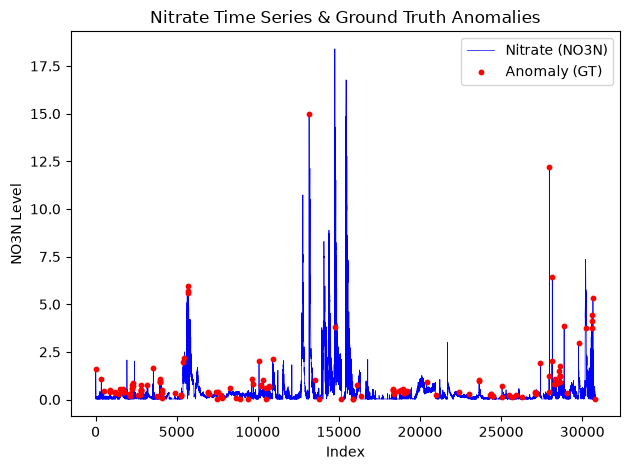

In [ ]:
#plt.figure(figsize=(14, 5))

plt.plot(df['NO3N'], label='Nitrate (NO3N)', color='blue', linewidth=0.5)

# Overlay ground-truth anomalies as a light scatter layer
anomalies = df[df['Student_Flag'] == 1]
plt.scatter(anomalies.index, anomalies['NO3N'], color='red', s=10, label='Anomaly (GT)', zorder=3)

plt.xlabel('Index')
plt.ylabel('NO3N Level')
plt.title('Nitrate Time Series & Ground Truth Anomalies')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
W = 2000  # Window size
q = 95    # Percentile threshold
values = df["NO3N"].values
n_points = len(values)

# Array to store predicted flags (0 for normal, 1 for anomaly)
pred_flags = np.zeros(n_points, dtype=int)


In [8]:
T1 = np.percentile(values[0:W], q, method="linear")
pred_flags[0:W] = (values[0:W] >= T1).astype(int)

In [9]:
for i in range(1, n_points - W + 1):
    window_data = values[i : i + W]
    Ti = np.percentile(window_data, q, method="linear")
    
    # Label only the new incoming point at the end of the window
    new_point_idx = i + W - 1
    if values[new_point_idx] >= Ti:
        pred_flags[new_point_idx] = 1

In [6]:
def extract_events(flags):
    # Find start and end indices of contiguous 1s
    diff = np.diff(np.pad(flags, (1, 1), 'constant'))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    return list(zip(starts, ends))

gt_events = extract_events(df["Student_Flag"].values)  # Total = 77
pred_events = extract_events(pred_flags)

# Calculate True Positives (TP) and False Negatives (FN)
TP = 0
for start, end in gt_events:
    # An anomaly event is correctly detected if your model flags AT LEAST 1 point inside the event interval
    if np.any(pred_flags[start:end] == 1):
        TP += 1

FN = len(gt_events) - TP  # Total GT events (77) - TP
anomaly_accuracy = TP / len(gt_events)

print(f"TP: {TP} / 77")
print(f"Anomaly Accuracy: {anomaly_accuracy * 100:.2f}%")

TP: 88 / 77
Anomaly Accuracy: 65.67%
